<a href="https://www.kaggle.com/code/sdhivyadharsrini/data-analyst-agent?scriptVersionId=284032668" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import os
from pathlib import Path

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report


class DataAnalystAgent:
    def __init__(self):
        self.raw_df = None
        self.df = None
        self.report_lines = []

    def load_data(self):
        """
        Look for CSV files under /kaggle/input/logamithran (recursively),
        and load the first one as the main dataset.
        """
        base = Path("/kaggle/input/logamithran")

        if not base.exists():
            raise FileNotFoundError(
                "Folder /kaggle/input/logamithran not found. "
                "Make sure you added the dataset with '+ Add data'."
            )

        print("Scanning for CSV files in:", base, "\n")

        csvs = []
        for root, dirs, files in os.walk(base):
            for f in files:
                if f.lower().endswith(".csv"):
                    csvs.append(Path(root) / f)

        if not csvs:
            raise FileNotFoundError(
                "No CSV files found inside /kaggle/input/logamithran.\n"
                "Check that your CSV is actually inside that dataset."
            )

        print("Found CSV files:")
        for c in csvs:
            print(" -", c)

        main_file = csvs[0]
        print("\nUsing:", main_file)

        self.raw_df = pd.read_csv(main_file)
        print("Data loaded. Shape:", self.raw_df.shape)

        self.report_lines.append(f"Dataset used: {main_file}")
        self.report_lines.append(f"Shape: {self.raw_df.shape}")

    def clean_data(self):
        """
        Simple generic cleaning:
        - numeric: fill NaN with median
        - categorical: fill NaN with mode
        """
        if self.raw_df is None:
            raise ValueError("You must call load_data() before clean_data().")

        df = self.raw_df.copy()

        num_cols = df.select_dtypes(include=[np.number]).columns
        cat_cols = df.select_dtypes(exclude=[np.number]).columns

        for col in num_cols:
            df[col] = df[col].fillna(df[col].median())

        for col in cat_cols:
            if df[col].isna().any():
                df[col] = df[col].fillna(df[col].mode()[0])

        self.df = df

        print("Cleaning completed. Remaining missing values:")
        print(self.df.isna().sum())

        self.report_lines.append("Data cleaned. Remaining missing values:")
        self.report_lines.append(str(self.df.isna().sum()))

    def basic_summary(self):
        print("\nFirst 5 rows:")
        display(self.df.head())

        print("\nInfo:")
        display(self.df.info())

        print("\nDescribe (numeric):")
        display(self.df.describe())

        self.report_lines.append("Basic numeric description:")
        self.report_lines.append(str(self.df.describe()))

    def univariate_analysis(self):
        """
        Plot distributions of up to 4 numeric columns.
        """
        sns.set(style="whitegrid")

        num_cols = list(self.df.select_dtypes(include=[np.number]).columns)
        # Don't include target in generic plots if we know it
        for t in ["Churn", "Survived", "target", "label"]:
            if t in num_cols:
                num_cols.remove(t)

        num_cols = num_cols[:4]

        for col in num_cols:
            plt.figure()
            sns.histplot(self.df[col], bins=30, kde=True)
            plt.title(f"Distribution of {col}")
            plt.tight_layout()
            plt.show()

        self.report_lines.append(f"Univariate analysis on numeric columns: {num_cols}")

    def simple_model(self):
        """
        Train a simple logistic regression if we can find a binary target
        (Churn, Survived, target, label).
        """
        # Find target column
        target_col = None
        for cand in ["Churn", "Survived", "target", "Target", "label"]:
            if cand in self.df.columns:
                target_col = cand
                break

        if target_col is None:
            print("No obvious target column found (Churn/Survived/target/label). Skipping model.")
            self.report_lines.append("No target column found. simple_model skipped.")
            return

        y = self.df[target_col]
        if y.nunique() != 2:
            print(f"Target column '{target_col}' is not binary (unique values = {y.nunique()}). Skipping model.")
            self.report_lines.append(f"Target {target_col} not binary. simple_model skipped.")
            return

        # Use numeric features except target
        feature_cols = [c for c in self.df.columns
                        if self.df[c].dtype != "object" and c != target_col]
        if not feature_cols:
            print("No numeric features available for modeling. Skipping.")
            self.report_lines.append("No numeric features. simple_model skipped.")
            return

        X = self.df[feature_cols]

        X_train, X_test, y_train, y_test = train_test_split(
            X, y, test_size=0.2, random_state=42
        )

        model = LogisticRegression(max_iter=1000)
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        print("\nLogistic Regression Accuracy:", acc)
        print("\nClassification report:")
        print(classification_report(y_test, y_pred))

        self.report_lines.append(f"Logistic regression accuracy: {acc:.4f}")
        self.report_lines.append("Classification report:")
        self.report_lines.append(classification_report(y_test, y_pred))

    def generate_report(self, filename="eda_report.txt"):
        text = "\n".join(str(line) for line in self.report_lines)
        out = Path("/kaggle/working") / filename
        with open(out, "w") as f:
            f.write(text)
        print("\nReport saved to:", out)
        return out

    def run_all(self):
        """
        Convenience method to run the full pipeline.
        """
        self.load_data()
        self.clean_data()
        self.basic_summary()
        self.univariate_analysis()
        self.simple_model()
        self.generate_report("eda_report.txt")


Scanning for CSV files in: /kaggle/input/logamithran 

Found CSV files:
 - /kaggle/input/logamithran/synthetic_customer_churn_dataset.csv

Using: /kaggle/input/logamithran/synthetic_customer_churn_dataset.csv
Data loaded. Shape: (200, 7)
Cleaning completed. Remaining missing values:
CustomerID        0
Age               0
MonthlySpend      0
TenureMonths      0
SupportTickets    0
IsPremiumUser     0
Churn             0
dtype: int64

First 5 rows:


,CustomerID,Age,MonthlySpend,TenureMonths,SupportTickets,IsPremiumUser,Churn
0,1,56,4081,25,8,1,0
1,2,46,3957,40,9,0,0
2,3,32,2136,45,9,0,0
3,4,60,4196,53,0,1,0
4,5,25,3499,1,5,1,0



Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 7 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   CustomerID      200 non-null    int64
 1   Age             200 non-null    int64
 2   MonthlySpend    200 non-null    int64
 3   TenureMonths    200 non-null    int64
 4   SupportTickets  200 non-null    int64
 5   IsPremiumUser   200 non-null    int64
 6   Churn           200 non-null    int64
dtypes: int64(7)
memory usage: 11.1 KB


None


Describe (numeric):


,CustomerID,Age,MonthlySpend,TenureMonths,SupportTickets,IsPremiumUser,Churn
count,200.000000,200.000000,200.000000,200.000000,200.000000,200.00000,200.000000
mean,100.500000,41.570000,2781.730000,30.635000,4.270000,0.50500,0.015000
std,57.879185,13.715527,1310.763128,16.391007,2.946269,0.50123,0.121857
min,1.000000,18.000000,504.000000,1.000000,0.000000,0.00000,0.000000
25%,50.750000,30.000000,1578.000000,16.750000,2.000000,0.00000,0.000000
50%,100.500000,42.000000,2847.500000,30.500000,4.000000,1.00000,0.000000
75%,150.250000,54.000000,3857.750000,45.000000,7.000000,1.00000,0.000000
max,200.000000,64.000000,4999.000000,59.000000,9.000000,1.00000,1.000000


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


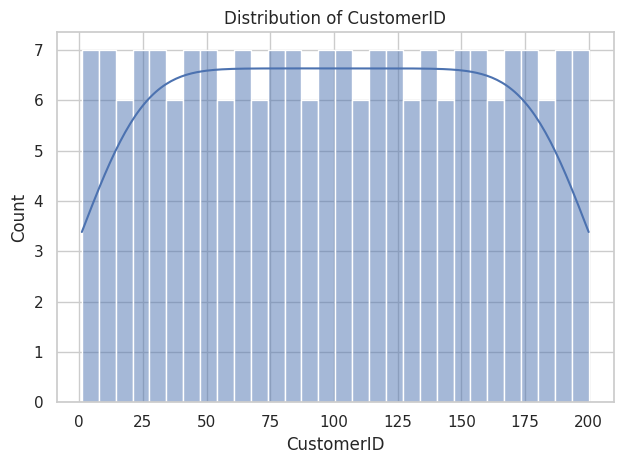

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


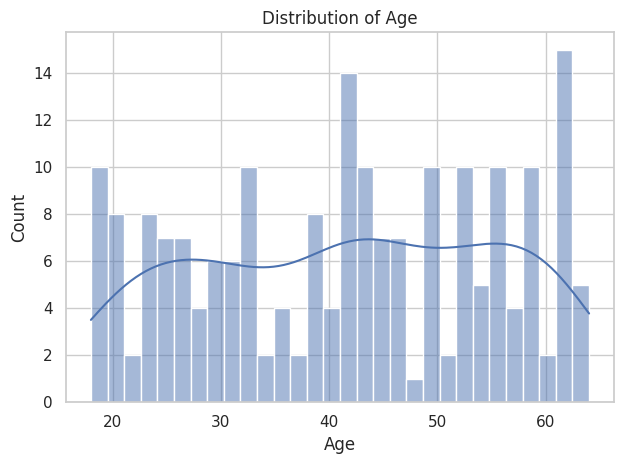

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


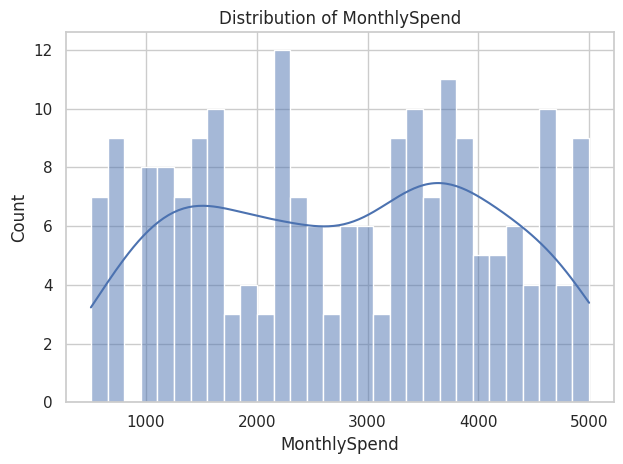

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


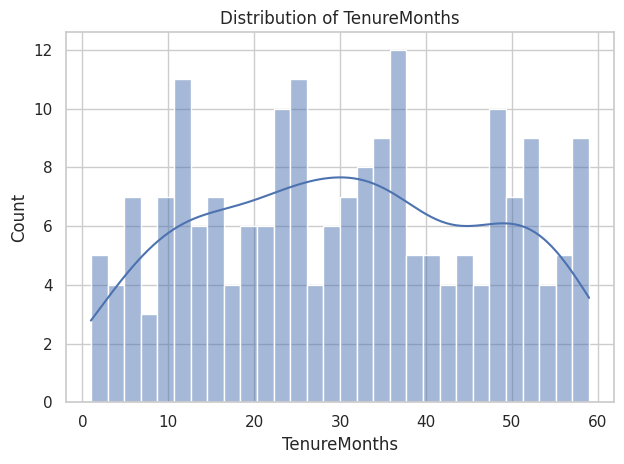


Logistic Regression Accuracy: 1.0

Classification report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        40

    accuracy                           1.00        40
   macro avg       1.00      1.00      1.00        40
weighted avg       1.00      1.00      1.00        40


Report saved to: /kaggle/working/eda_report.txt


In [2]:
agent = DataAnalystAgent()
agent.run_all()
